# Food Delivery Time Prediction

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

In [2]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")


In [3]:
df.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [4]:
df.tail(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
990,122,17.97,Windy,Medium,Morning,Scooter,28,7.0,92
991,615,17.53,Clear,Low,Afternoon,Bike,14,6.0,79
992,21,12.43,Rainy,High,Morning,Bike,13,6.0,70
993,701,10.89,Windy,Medium,Evening,Bike,7,0.0,58
994,72,4.37,Clear,Medium,Evening,Scooter,6,7.0,25
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.shape

(1000, 9)

In [7]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.isnull().all(axis=1)]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [10]:
df[df.isnull().any(axis=1)]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
14,939,2.80,Clear,High,Morning,Scooter,10,NaN,33
24,211,11.20,Clear,Medium,Morning,Bike,23,NaN,73
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,494,4.17,NaN,Low,Evening,Scooter,5,1.0,22
...,...,...,...,...,...,...,...,...,...
974,414,11.68,Clear,NaN,Afternoon,Scooter,25,7.0,70
976,344,8.96,Snowy,NaN,Morning,Car,6,5.0,51
987,331,7.44,Rainy,Low,Evening,Bike,27,NaN,53
988,215,14.39,Rainy,Medium,Morning,Scooter,6,NaN,50


In [11]:
df = df.dropna()
df.shape

(883, 9)

In [12]:
df = df.drop("Order_ID", axis=1)
df.shape

(883, 8)

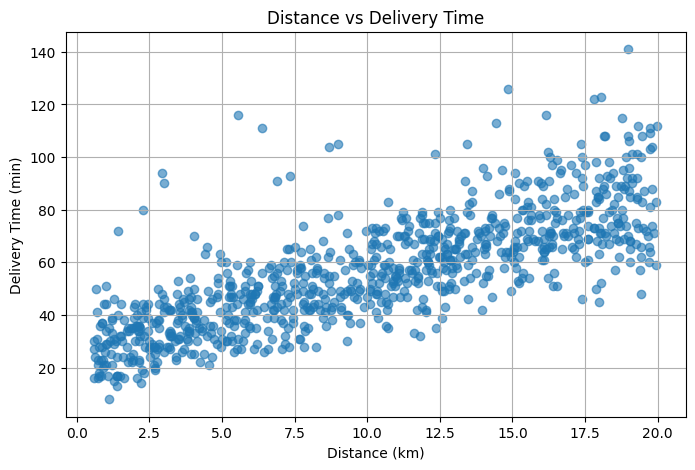

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["Distance_km"],
    df["Delivery_Time_min"],
    alpha=0.6
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")

plt.grid(True)

plt.show()

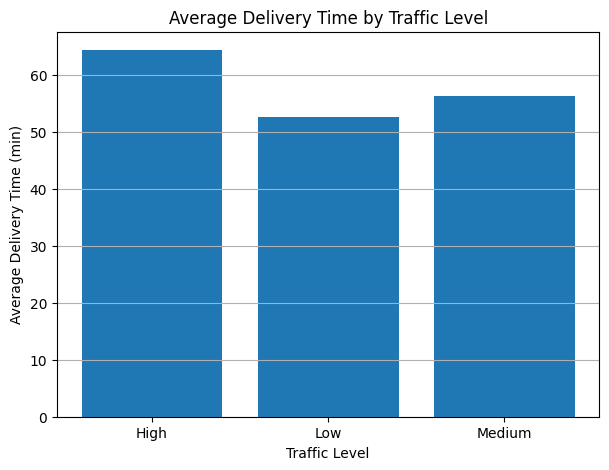

In [67]:
import matplotlib.pyplot as plt

avg_delivery = df.groupby("Traffic_Level")["Delivery_Time_min"].mean()

plt.figure(figsize=(7,5))
plt.bar(avg_delivery.index, avg_delivery.values)

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (min)")
plt.grid(axis="y")

plt.show()

<Figure size 800x500 with 0 Axes>

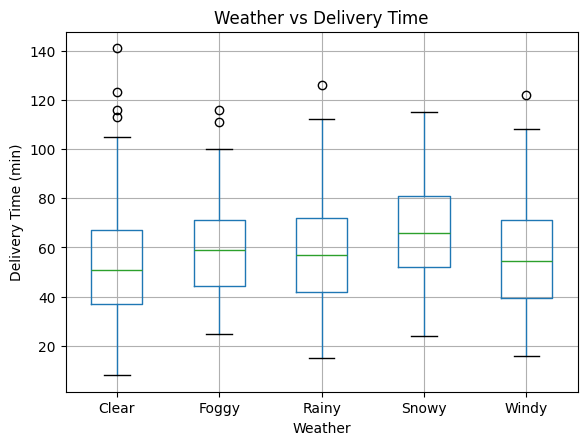

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="Delivery_Time_min", by="Weather")

plt.title("Weather vs Delivery Time")
plt.suptitle("")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (min)")

plt.show()

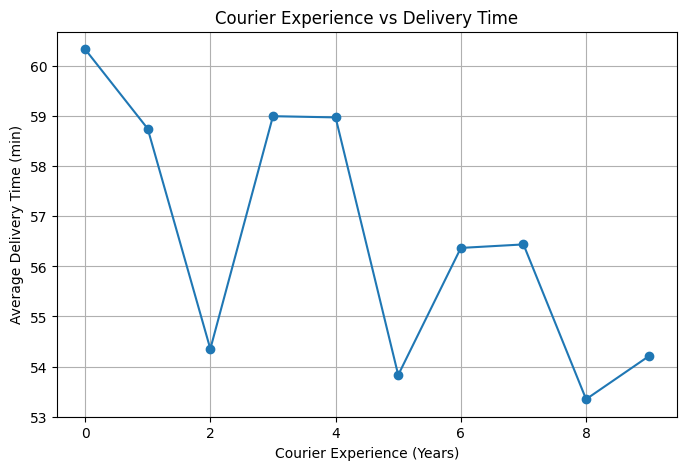

In [72]:
import matplotlib.pyplot as plt

avg_exp = df.groupby("Courier_Experience_yrs")["Delivery_Time_min"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_exp.index, avg_exp.values, marker="o")

plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Average Delivery Time (min)")
plt.grid(True)

plt.show()

In [13]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

In [45]:
X = pd.get_dummies(
    X,
    columns=["Weather", "Vehicle_Type"],
    dtype=int
)

In [47]:
X["Traffic_Level"] = X["Traffic_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [48]:
X["Time_of_Day"] = X["Time_of_Day"].map({
    "Morning": 0,
    "Afternoon": 1,
    "Evening": 2,
    "Night": 3
})

In [27]:
X.dtypes

,0
Distance_km,float64
Traffic_Level,float64
Time_of_Day,int64
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Weather_Clear,int64
Weather_Foggy,int64
Weather_Rainy,int64
Weather_Snowy,int64
Weather_Windy,int64


In [39]:
X.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
X_train.shape, X_test.shape

((706, 13), (177, 13))

In [52]:
model = LinearRegression()

In [53]:
model.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred = model.predict(X_test)

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [78]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5.284153269666747
MSE: 67.31418918647668
R2 Score: 0.8353049464893283


In [77]:
import numpy as np

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 6.791864406779662
RMSE : 9.868540381714853
R2 Score : 0.7617242847795911


In [60]:
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 8.204522483757156


In [79]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

print()

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Linear Regression Results
MAE: 5.284153269666747
RMSE: 8.204522483757156
R2 Score: 0.8353049464893283

Random Forest Results
MAE: 6.791864406779662
RMSE: 9.868540381714853
R2 Score: 0.7617242847795911


Key Insights

1. Delivery distance has a direct impact on delivery time. As the distance increases, the delivery time also increases.

2. High traffic conditions generally increase the delivery time compared to low traffic.

3. Weather conditions also affect delivery time, especially during rainy and foggy weather.

4. Courier experience helps improve delivery efficiency and can reduce delivery time.

5. After comparing both models, Linear Regression performed better than Random Forest for this dataset.

In [80]:
new_data = pd.DataFrame({
    "Distance_km": [10],
    "Traffic_Level": [2],
    "Time_of_Day": [1],
    "Preparation_Time_min": [15],
    "Courier_Experience_yrs": [3],
    "Weather_Clear": [1],
    "Weather_Foggy": [0],
    "Weather_Rainy": [0],
    "Weather_Snowy": [0],
    "Weather_Windy": [0],
    "Vehicle_Type_Bike": [1],
    "Vehicle_Type_Car": [0],
    "Vehicle_Type_Scooter": [0]
})

prediction = model.predict(new_data)

print("Predicted Delivery Time:", round(prediction[0], 2), "minutes")

Predicted Delivery Time: 59.87 minutes


Conclusion

Linear Regression and Random Forest models were trained and tested.

After comparing the results, Linear Regression performed better because it achieved a higher R² score and lower MAE and RMSE values than Random Forest.

Therefore, Linear Regression is selected as the final model for predicting delivery time.